In [1]:
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from generate_data import load_model, load_saved_data, eval_accuracy

ROOT = Path('.').resolve()
CKPT = ROOT / 'models' / 'pretrain_ckpt.pt'
DATA_PKL = ROOT / '_data.pkl'

# Keep this editable for quick experiments: p_target:steps
STAGES = '0.8:100'
LR = 1e-4
WEIGHT_DECAY = 0 #1e-3
BATCH_SIZE = 128
SEED = 107
VAL_EVERY = 1
VAL_MAX_SAMPLES = 500  # per split (other/burst). Lower = faster validation.

print('ROOT:', ROOT)
print('CKPT exists:', CKPT.exists())
print('DATA_PKL exists:', DATA_PKL.exists())

def parse_stages(stages_str):
    stages = []
    for idx, chunk in enumerate(stages_str.split(','), start=1):
        p_str, steps_str = chunk.strip().split(':')
        p_target = float(p_str)
        steps = int(steps_str)
        stages.append({'name': f'stage_{idx}', 'p_target': p_target, 'steps': steps})
    return stages


def flatten_pool(pool_dict):
    return [docs for _, docs in pool_dict.items()]


def sample_batch(target_pool_flat, bg_pool_flat, batch_size, p_target, rng):
    batch = []
    for _ in range(batch_size):
        pool = target_pool_flat if rng.random() < p_target else bg_pool_flat
        task_docs = pool[rng.integers(0, len(pool))]
        doc = task_docs[rng.integers(0, len(task_docs))]
        batch.append(doc)
    return np.stack(batch, axis=0)

ROOT: /workspace/tinystoriesFT/sunny
CKPT exists: True
DATA_PKL exists: True


Validation docs used (task-holdout): other=500, burst=200; val_tasks other=5 burst=2
Forgetting phase steps: 10
step=0 stage=pretrained phase=baseline val_other_acc=1.0000 val_burst_acc=0.0233
step=1 stage=stage_1 phase=finetune loss=1.627934 train_acc=1.0000 val_other_acc=0.4332 val_burst_acc=0.1208
step=2 stage=stage_1 phase=finetune loss=1.658989 train_acc=0.8672 val_other_acc=0.6125 val_burst_acc=0.2542
step=3 stage=stage_1 phase=finetune loss=1.360355 train_acc=0.9206 val_other_acc=0.6046 val_burst_acc=0.3017
step=4 stage=stage_1 phase=finetune loss=1.305053 train_acc=0.8919 val_other_acc=0.6144 val_burst_acc=0.3942
step=5 stage=stage_1 phase=finetune loss=1.163806 train_acc=0.9557 val_other_acc=0.6057 val_burst_acc=0.4292
step=6 stage=stage_1 phase=finetune loss=1.088256 train_acc=0.9362 val_other_acc=0.6707 val_burst_acc=0.5008
step=7 stage=stage_1 phase=finetune loss=1.038838 train_acc=0.9766 val_other_acc=0.6748 val_burst_acc=0.5700
step=8 stage=stage_1 phase=finetune loss=1.0

step=9 stage=stage_1 phase=finetune loss=1.006213 train_acc=0.9870 val_other_acc=0.6140 val_burst_acc=0.7658
step=10 stage=stage_1 phase=finetune loss=0.971262 train_acc=0.9727 val_other_acc=0.6152 val_burst_acc=0.8233
step=11 stage=stage_1 phase=finetune loss=0.942902 train_acc=0.9909 val_other_acc=0.6378 val_burst_acc=0.8358
step=12 stage=stage_1 phase=finetune loss=0.924719 train_acc=0.9883 val_other_acc=0.6455 val_burst_acc=0.8617
step=13 stage=stage_1 phase=finetune loss=0.910356 train_acc=0.9831 val_other_acc=0.6332 val_burst_acc=0.9117
step=14 stage=stage_1 phase=finetune loss=0.892743 train_acc=0.9922 val_other_acc=0.6468 val_burst_acc=0.9383
step=15 stage=stage_1 phase=finetune loss=0.881881 train_acc=0.9935 val_other_acc=0.6749 val_burst_acc=0.9625
step=16 stage=stage_1 phase=finetune loss=0.865319 train_acc=0.9948 val_other_acc=0.7116 val_burst_acc=0.9708
step=17 stage=stage_1 phase=finetune loss=0.852133 train_acc=0.9974 val_other_acc=0.7411 val_burst_acc=0.9700
step=18 sta

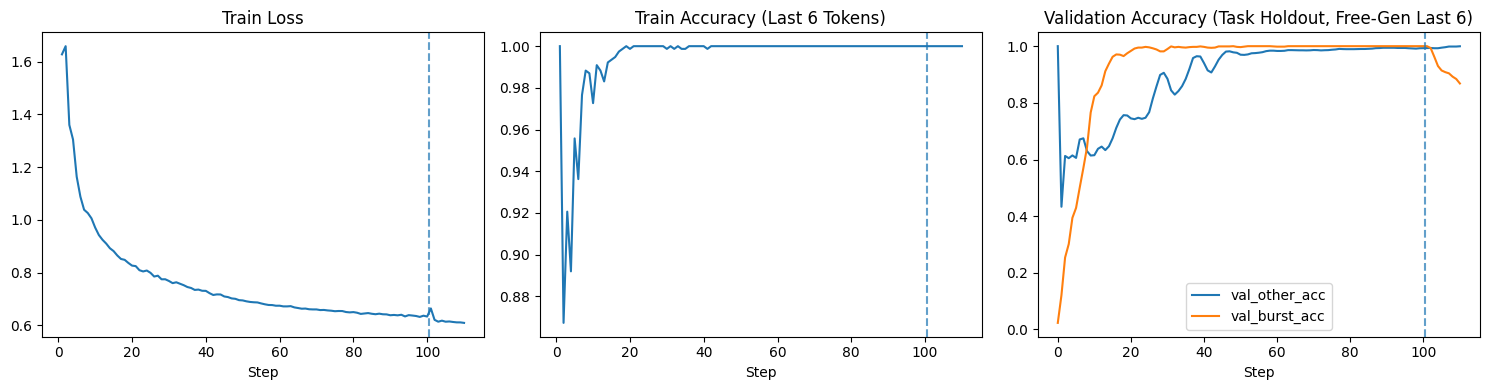

In [2]:
from generate_data import DepthNData, DATA_SEED, N_A

stages = parse_stages(STAGES)
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

data = load_saved_data(str(DATA_PKL))
target_pool_dict = data['target_pool']
bg_pool_dict = data['bg_pool']
prompt_len = int(data['prompt_len'])

# Hold out entire tasks for validation (stricter than doc-level holdout).
VAL_TASK_FRAC = 0.2
VAL_DOCS_PER_TASK = 100


def split_task_holdout(pool_dict, val_task_frac=0.2, val_docs_per_task=100):
    keys = list(pool_dict.keys())
    n_tasks = len(keys)
    if n_tasks == 0:
        return [], np.empty((0, 1), dtype=np.int64), []

    if n_tasks == 1:
        only_docs = pool_dict[keys[0]]
        take = min(val_docs_per_task, len(only_docs))
        val_idx = rng.choice(len(only_docs), size=take, replace=False)
        val_docs = only_docs[val_idx] if take > 0 else np.empty((0, only_docs.shape[1]), dtype=only_docs.dtype)
        return [only_docs], val_docs, [keys[0]]

    n_val_tasks = int(round(n_tasks * val_task_frac))
    n_val_tasks = max(1, min(n_val_tasks, n_tasks - 1))

    perm = rng.permutation(n_tasks)
    val_task_idx = set(perm[:n_val_tasks].tolist())

    train_pool_flat = []
    val_chunks = []
    val_task_keys = []

    for i, k in enumerate(keys):
        docs = pool_dict[k]
        if i in val_task_idx:
            val_task_keys.append(k)
            take = min(val_docs_per_task, len(docs))
            if take > 0:
                idx = rng.choice(len(docs), size=take, replace=False)
                val_chunks.append(docs[idx])
        else:
            train_pool_flat.append(docs)

    seq_len = next(iter(pool_dict.values())).shape[1]
    val_docs = np.concatenate(val_chunks, axis=0) if len(val_chunks) > 0 else np.empty((0, seq_len), dtype=np.int64)
    return train_pool_flat, val_docs, val_task_keys


def last6_acc_from_logits(logits, batch):
    pred = logits[:, :-1, :].argmax(dim=-1)
    target = batch[:, 1:]
    ml = min(pred.shape[1], target.shape[1])
    last6 = max(0, ml - 6)
    return float((pred[:, last6:ml] == target[:, last6:ml]).float().mean().item())


@torch.no_grad()
def eval_freegen_last6_acc(model, docs_np, prompt_len, device='cpu', batch_size=256):
    if docs_np.shape[0] == 0:
        return float('nan')
    model.eval()
    vals = []
    target_len = docs_np.shape[1] - prompt_len
    for start in range(0, docs_np.shape[0], batch_size):
        end = min(start + batch_size, docs_np.shape[0])
        chunk = docs_np[start:end]
        prompt_bt = torch.as_tensor(chunk[:, :prompt_len], dtype=torch.long, device=device)
        full = model.generate(prompt_bt, target_len)
        gen_np = full[:, prompt_len:].detach().cpu().numpy()
        gold_np = chunk[:, prompt_len:]
        ml = min(gen_np.shape[1], gold_np.shape[1])
        last6 = max(0, ml - 6)
        vals.append(float((gen_np[:, last6:ml] == gold_np[:, last6:ml]).mean()))
    model.train()
    return float(np.mean(vals))


# Split train pools / validation holdouts by task identity
target_pool, val_burst_docs, burst_val_tasks = split_task_holdout(
    target_pool_dict, val_task_frac=VAL_TASK_FRAC, val_docs_per_task=VAL_DOCS_PER_TASK
)
bg_pool, val_other_docs, other_val_tasks = split_task_holdout(
    bg_pool_dict, val_task_frac=VAL_TASK_FRAC, val_docs_per_task=VAL_DOCS_PER_TASK
)

# Cap validation set size for speed
if val_other_docs.shape[0] > VAL_MAX_SAMPLES:
    idx = rng.choice(val_other_docs.shape[0], size=VAL_MAX_SAMPLES, replace=False)
    val_other_docs = val_other_docs[idx]
if val_burst_docs.shape[0] > VAL_MAX_SAMPLES:
    idx = rng.choice(val_burst_docs.shape[0], size=VAL_MAX_SAMPLES, replace=False)
    val_burst_docs = val_burst_docs[idx]

print(
    f"Validation docs used (task-holdout): other={len(val_other_docs)}, burst={len(val_burst_docs)}; "
    f"val_tasks other={len(other_val_tasks)} burst={len(burst_val_tasks)}"
)

# Fixed debug prompts to compare end-of-finetune vs end-of-forgetting generations
decoder = DepthNData(n_alph=10, seq_len=6, n_a=N_A, depth=3, burst_pos=1, seed=DATA_SEED)
DEBUG_SAMPLES_PER_SPLIT = 3
debug_rows = []
debug_labels = []
for docs, label in [(val_burst_docs, 'burst'), (val_other_docs, 'other')]:
    take = min(DEBUG_SAMPLES_PER_SPLIT, len(docs))
    for i in range(take):
        debug_rows.append(docs[i])
        debug_labels.append(label)

if len(debug_rows) > 0:
    debug_docs_np = np.stack(debug_rows, axis=0)
    debug_prompt_np = debug_docs_np[:, :prompt_len]
    debug_target_np = debug_docs_np[:, prompt_len:]
else:
    debug_docs_np = np.empty((0, 1), dtype=np.int64)
    debug_prompt_np = np.empty((0, 1), dtype=np.int64)
    debug_target_np = np.empty((0, 1), dtype=np.int64)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
net = load_model(str(CKPT), device=device)
net.train()
# optimizer = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
optimizer = torch.optim.Adam(net.parameters(), lr=LR, )

# Add a short forgetting phase after all configured finetune stages
FORGET_STEPS = max(1, stages[-1]['steps'] // 10)
print(f"Forgetting phase steps: {FORGET_STEPS}")

history = {
    'loss': [],
    'train_acc': [],
    'val_other_acc': [],
    'val_burst_acc': [],
    'global_step': [],
    'val_step': [],
    'phase': [],
}

# Pretrained baseline on task-holdout validation sets (free-generation last-6)
pre_val_other_acc = eval_freegen_last6_acc(net, val_other_docs, prompt_len=prompt_len, device=device)
pre_val_burst_acc = eval_freegen_last6_acc(net, val_burst_docs, prompt_len=prompt_len, device=device)
history['val_other_acc'].append(pre_val_other_acc)
history['val_burst_acc'].append(pre_val_burst_acc)
history['val_step'].append(0)
print(
    f"step=0 stage=pretrained phase=baseline val_other_acc={pre_val_other_acc:.4f} "
    f"val_burst_acc={pre_val_burst_acc:.4f}"
)


@torch.no_grad()
def print_debug_generations(model, tag):
    if debug_prompt_np.shape[0] == 0:
        print(f"\n=== {tag}: no debug prompts available ===")
        return

    model.eval()
    prompt_bt = torch.as_tensor(debug_prompt_np, dtype=torch.long, device=device)
    n_new = debug_target_np.shape[1]
    full = model.generate(prompt_bt, n_new)
    gen_np = full[:, prompt_len:].detach().cpu().numpy()

    print(f"\n=== Sample generations: {tag} ===")
    for i in range(debug_prompt_np.shape[0]):
        label = debug_labels[i]
        prompt_txt = decoder.decode(debug_prompt_np[i])
        target_txt = decoder.decode(debug_target_np[i])
        gen_txt = decoder.decode(gen_np[i])
        print(f"[{i:02d}] {label}")
        print('prompt:', prompt_txt)
        print('target:', target_txt)
        print('model :', gen_txt)
        print('-' * 80)
    model.train()

global_step = 0
for stage in stages:
    for stage_step in range(1, stage['steps'] + 1):
        global_step += 1

        batch_np = sample_batch(target_pool, bg_pool, BATCH_SIZE, stage['p_target'], rng)
        batch = torch.as_tensor(batch_np, dtype=torch.long, device=device)

        logits = net(batch)
        loss = F.cross_entropy(
            logits[:, :-1, :].reshape(-1, logits.size(-1)),
            batch[:, 1:].reshape(-1),
        )
        train_acc = last6_acc_from_logits(logits, batch)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        history['loss'].append(loss.item())
        history['train_acc'].append(train_acc)
        history['global_step'].append(global_step)
        history['phase'].append('finetune')

        do_val = (global_step % VAL_EVERY == 0)
        if do_val:
            val_other_acc = eval_freegen_last6_acc(net, val_other_docs, prompt_len=prompt_len, device=device)
            val_burst_acc = eval_freegen_last6_acc(net, val_burst_docs, prompt_len=prompt_len, device=device)
            history['val_other_acc'].append(val_other_acc)
            history['val_burst_acc'].append(val_burst_acc)
            history['val_step'].append(global_step)
            print(
                f"step={global_step} stage={stage['name']} phase=finetune "
                f"loss={loss.item():.6f} train_acc={train_acc:.4f} "
                f"val_other_acc={val_other_acc:.4f} val_burst_acc={val_burst_acc:.4f}"
            )
        else:
            print(
                f"step={global_step} stage={stage['name']} phase=finetune "
                f"loss={loss.item():.6f} train_acc={train_acc:.4f}"
            )

# Debug snapshot right after finetuning, before forgetting
print_debug_generations(net, tag='end_of_finetune')

# Forgetting stage: train briefly on original/background-only data
for forget_step in range(1, FORGET_STEPS + 1):
    global_step += 1

    batch_np = sample_batch(target_pool, bg_pool, BATCH_SIZE, 0.0, rng)
    batch = torch.as_tensor(batch_np, dtype=torch.long, device=device)

    logits = net(batch)
    loss = F.cross_entropy(
        logits[:, :-1, :].reshape(-1, logits.size(-1)),
        batch[:, 1:].reshape(-1),
    )
    train_acc = last6_acc_from_logits(logits, batch)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    history['loss'].append(loss.item())
    history['train_acc'].append(train_acc)
    history['global_step'].append(global_step)
    history['phase'].append('forget')

    do_val = (global_step % VAL_EVERY == 0)
    if do_val:
        val_other_acc = eval_freegen_last6_acc(net, val_other_docs, prompt_len=prompt_len, device=device)
        val_burst_acc = eval_freegen_last6_acc(net, val_burst_docs, prompt_len=prompt_len, device=device)
        history['val_other_acc'].append(val_other_acc)
        history['val_burst_acc'].append(val_burst_acc)
        history['val_step'].append(global_step)
        print(
            f"step={global_step} stage=forget phase=forget "
            f"loss={loss.item():.6f} train_acc={train_acc:.4f} "
            f"val_other_acc={val_other_acc:.4f} val_burst_acc={val_burst_acc:.4f}"
        )
    else:
        print(
            f"step={global_step} stage=forget phase=forget "
            f"loss={loss.item():.6f} train_acc={train_acc:.4f}"
        )

# Debug snapshot at the end of forgetting
print_debug_generations(net, tag='end_of_forgetting')

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
forget_start = history['global_step'][-FORGET_STEPS] - 0.5
ax[0].plot(history['global_step'], history['loss'])
ax[0].axvline(forget_start, linestyle='--', alpha=0.7)
ax[0].set_title('Train Loss')
ax[0].set_xlabel('Step')

ax[1].plot(history['global_step'], history['train_acc'])
ax[1].axvline(forget_start, linestyle='--', alpha=0.7)
ax[1].set_title('Train Accuracy (Last 6 Tokens)')
ax[1].set_xlabel('Step')

ax[2].plot(history['val_step'], history['val_other_acc'], label='val_other_acc')
ax[2].plot(history['val_step'], history['val_burst_acc'], label='val_burst_acc')
ax[2].axvline(forget_start, linestyle='--', alpha=0.7)
ax[2].set_title('Validation Accuracy (Task Holdout, Free-Gen Last 6)')
ax[2].set_xlabel('Step')
ax[2].legend()

plt.tight_layout()
plt.show()

In [3]:
# Print 10 random samples and mark whether they are from target or background.
from generate_data import DepthNData, DATA_SEED, N_A

n_show = 10
p_new = stage.get("p_target", 0.5) if isinstance(stage, dict) else 0.5

# Decoder for this synthetic dataset format
decoder = DepthNData(n_alph=10, seq_len=6, n_a=N_A, depth=3, burst_pos=1, seed=DATA_SEED)

for i in range(1, n_show + 1):
    is_new = rng.random() < p_new
    pool = target_pool if is_new else bg_pool

    task_docs = pool[rng.integers(0, len(pool))]
    sample = task_docs[rng.integers(0, len(task_docs))]

    tag = "target" if is_new else "background"
    try:
        decoded = decoder.decode(sample)
    except Exception:
        decoded = " ".join(map(str, sample.tolist()))

    print(f"[{i:02d}] {tag}: {decoded}")
    print(f"[{i:02d}] {tag}: {sample.tolist()}")
    print("-" * 80)

[01] background: S F1 F1 F1   X0 X7 X2 X6 X4 X9   X6 X1 X8 X9 X3 X0   X9 X2 X5 X0 X4 X6   X0 X8 X7 X6 X3 X9
[01] background: [17, 11, 11, 11, 15, 0, 7, 2, 6, 4, 9, 15, 6, 1, 8, 9, 3, 0, 15, 9, 2, 5, 0, 4, 6, 15, 0, 8, 7, 6, 3, 9]
--------------------------------------------------------------------------------
[02] target: S F1 F2 F4   X2 X1 X1 X3 X2 X7   X2 X1 X1 X6 X2 X5   X1 X4 X4 X7 X1 X6   X2 X3 X3 X1 X2 X9
[02] target: [17, 11, 12, 14, 15, 2, 1, 1, 3, 2, 7, 15, 2, 1, 1, 6, 2, 5, 15, 1, 4, 4, 7, 1, 6, 15, 2, 3, 3, 1, 2, 9]
--------------------------------------------------------------------------------
[03] target: S F2 F2 F4   X0 X7 X1 X9 X3 X6   X7 X5 X1 X0 X6 X3   X9 X6 X4 X8 X7 X3   X0 X7 X2 X5 X9 X3
[03] target: [17, 12, 12, 14, 15, 0, 7, 1, 9, 3, 6, 15, 7, 5, 1, 0, 6, 3, 15, 9, 6, 4, 8, 7, 3, 15, 0, 7, 2, 5, 9, 3]
--------------------------------------------------------------------------------
[04] target: S F2 F3 F4   X0 X0 X0 X9 X5 X9   X7 X7 X7 X0 X8 X0   X2 X2 X2 X9 X6 X9

Now try to interp some stuff

In [4]:
# Stage sweep over p_target with a short post-finetune forgetting phase (p_target=0.0).
from generate_data import DepthNData, DATA_SEED, N_A

# Interpret STAGES step count as the baseline budget for p_target=0.25.
steps_at_p25 = parse_stages(STAGES)[0]['steps']
stage_types = [0.25, 0.33, 0.5, 0.7, 0.8, 0.9]

# Keep expected special samples roughly fixed across p_target by scaling steps as (0.25 / p_target).
# Example: p=0.25 gets 4x steps of p=1.0.
SPECIAL_TARGET_FRAC = 0.25

# Hold out validation prompts from each pool
VAL_FRAC = 0.1
VAL_MAX_PER_SPLIT = VAL_MAX_SAMPLES if 'VAL_MAX_SAMPLES' in globals() else 500
EVAL_EVERY = 1

rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

data = load_saved_data(str(DATA_PKL))
target_pool_all = flatten_pool(data['target_pool'])
bg_pool_all = flatten_pool(data['bg_pool'])
prompt_len = int(data['prompt_len'])
seq_len = int(target_pool_all[0].shape[1])


def split_pool_train_val(pool_flat, val_frac=0.1):
    train_pool = []
    val_rows = []
    for docs in pool_flat:
        n = len(docs)
        if n <= 1:
            train_pool.append(docs)
            continue

        n_val = int(round(n * val_frac))
        n_val = max(1, min(n_val, n - 1))

        # Shuffle per task so holdout isn't positional
        idx = rng.permutation(n)
        val_idx = idx[:n_val]
        train_idx = idx[n_val:]

        train_docs = docs[train_idx]
        val_docs = docs[val_idx]

        train_pool.append(train_docs)
        val_rows.append(val_docs)

    if len(val_rows) == 0:
        return train_pool, np.empty((0, seq_len), dtype=np.int64)

    val_concat = np.concatenate(val_rows, axis=0)
    return train_pool, val_concat


def eval_loss(model, docs_np, device='cpu', batch_size=256):
    if docs_np.shape[0] == 0:
        return float('nan')

    model.eval()
    losses = []
    with torch.no_grad():
        for start in range(0, docs_np.shape[0], batch_size):
            end = min(start + batch_size, docs_np.shape[0])
            batch = torch.as_tensor(docs_np[start:end], dtype=torch.long, device=device)
            logits = model(batch)
            loss = F.cross_entropy(
                logits[:, :-1, :].reshape(-1, logits.size(-1)),
                batch[:, 1:].reshape(-1),
            )
            losses.append(float(loss.item()))
    model.train()
    return float(np.mean(losses))


def last6_acc_from_logits(logits, batch):
    pred = logits[:, :-1, :].argmax(dim=-1)
    target = batch[:, 1:]
    ml = min(pred.shape[1], target.shape[1])
    last6 = max(0, ml - 6)
    return float((pred[:, last6:ml] == target[:, last6:ml]).float().mean().item())


def eval_freegen_last6_acc(model, docs_np, prompt_len, device='cpu', batch_size=256):
    if docs_np.shape[0] == 0:
        return float('nan')

    model.eval()
    acc_vals = []
    with torch.no_grad():
        target_len = docs_np.shape[1] - prompt_len
        for start in range(0, docs_np.shape[0], batch_size):
            end = min(start + batch_size, docs_np.shape[0])
            chunk = docs_np[start:end]
            prompt_bt = torch.as_tensor(chunk[:, :prompt_len], dtype=torch.long, device=device)
            full = model.generate(prompt_bt, target_len)
            gen_np = full[:, prompt_len:].detach().cpu().numpy()
            gold_np = chunk[:, prompt_len:]
            ml = min(gen_np.shape[1], gold_np.shape[1])
            last6 = max(0, ml - 6)
            acc_vals.append(float((gen_np[:, last6:ml] == gold_np[:, last6:ml]).mean()))
    model.train()
    return float(np.mean(acc_vals))


# Split into train pools + held-out validation sets
target_pool, val_special_docs = split_pool_train_val(target_pool_all, val_frac=VAL_FRAC)
bg_pool, val_normal_docs = split_pool_train_val(bg_pool_all, val_frac=VAL_FRAC)

# Cap validation size for speed
if val_special_docs.shape[0] > VAL_MAX_PER_SPLIT:
    idx = rng.choice(val_special_docs.shape[0], size=VAL_MAX_PER_SPLIT, replace=False)
    val_special_docs = val_special_docs[idx]
if val_normal_docs.shape[0] > VAL_MAX_PER_SPLIT:
    idx = rng.choice(val_normal_docs.shape[0], size=VAL_MAX_PER_SPLIT, replace=False)
    val_normal_docs = val_normal_docs[idx]

print(
    f"Validation docs: special={val_special_docs.shape[0]} normal={val_normal_docs.shape[0]} "
    f"(val_frac={VAL_FRAC}, eval_every={EVAL_EVERY})"
)

# Keep decoder/probe sampling available for consistency with nearby analysis cells
decoder = DepthNData(n_alph=10, seq_len=6, n_a=N_A, depth=3, burst_pos=1, seed=DATA_SEED)
n_per_class = 10
probe_rows = []
for _ in range(n_per_class):
    task_docs = target_pool[rng.integers(0, len(target_pool))]
    sample = task_docs[rng.integers(0, len(task_docs))]
    probe_rows.append(sample[:prompt_len])
for _ in range(n_per_class):
    task_docs = bg_pool[rng.integers(0, len(bg_pool))]
    sample = task_docs[rng.integers(0, len(task_docs))]
    probe_rows.append(sample[:prompt_len])
probe_batch = torch.as_tensor(np.stack(probe_rows), dtype=torch.long, device=device)
print('Probe prompts:', probe_batch.shape[0])

# Pretrained baseline on held-out sets (free-generation last-6)
pretrained_net = load_model(str(CKPT), device=device)
pre_special_acc = eval_freegen_last6_acc(pretrained_net, val_special_docs, prompt_len=prompt_len, device=device)
pre_normal_acc = eval_freegen_last6_acc(pretrained_net, val_normal_docs, prompt_len=prompt_len, device=device)
print(
    f"Pretrained baseline: special_val_acc={pre_special_acc:.4f} "
    f"normal_val_acc={pre_normal_acc:.4f}"
)
del pretrained_net

results = {}

for p_target in stage_types:
    finetune_steps = max(1, int(round(steps_at_p25 * (SPECIAL_TARGET_FRAC / p_target))))
    forget_steps = max(1, finetune_steps // 10) * 20
    print(
        f"\n=== Running loss/acc track for p_target={p_target} "
        f"(finetune_steps={finetune_steps}, forget_steps={forget_steps}) ==="
    )

    # fresh trainable model per stage type
    net = load_model(str(CKPT), device=device)
    net.train()
    optimizer = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    loss_history = []
    train_acc_history = []
    step_history = []
    phase_history = []
    val_steps = []
    special_val_loss = []
    normal_val_loss = []
    special_val_acc = []
    normal_val_acc = []

    # Phase 1: finetune on target-heavy mix
    for step in range(1, finetune_steps + 1):
        batch_np = sample_batch(target_pool, bg_pool, BATCH_SIZE, p_target, rng)
        batch = torch.as_tensor(batch_np, dtype=torch.long, device=device)

        logits = net(batch)
        loss = F.cross_entropy(
            logits[:, :-1, :].reshape(-1, logits.size(-1)),
            batch[:, 1:].reshape(-1),
        )
        tr_acc = last6_acc_from_logits(logits, batch)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        loss_history.append(float(loss.item()))
        train_acc_history.append(tr_acc)
        step_history.append(step)
        phase_history.append('finetune')

        if step % EVAL_EVERY == 0:
            sp_loss = eval_loss(net, val_special_docs, device=device)
            nm_loss = eval_loss(net, val_normal_docs, device=device)
            sp_acc = eval_freegen_last6_acc(net, val_special_docs, prompt_len=prompt_len, device=device)
            nm_acc = eval_freegen_last6_acc(net, val_normal_docs, prompt_len=prompt_len, device=device)
            val_steps.append(step)
            special_val_loss.append(sp_loss)
            normal_val_loss.append(nm_loss)
            special_val_acc.append(sp_acc)
            normal_val_acc.append(nm_acc)
            print(
                f"p={p_target} phase=finetune step={step} "
                f"train_loss={loss.item():.6f} train_acc={tr_acc:.4f} "
                f"special_val_loss={sp_loss:.6f} normal_val_loss={nm_loss:.6f} "
                f"special_val_acc={sp_acc:.4f} normal_val_acc={nm_acc:.4f}"
            )
        else:
            print(f"p={p_target} phase=finetune step={step} train_loss={loss.item():.6f} train_acc={tr_acc:.4f}")

    # Phase 2: forgetting stage on original/background data (p_target=0.0)
    for forget_step in range(1, forget_steps + 1):
        step = finetune_steps + forget_step
        batch_np = sample_batch(target_pool, bg_pool, BATCH_SIZE, 0.0, rng)
        batch = torch.as_tensor(batch_np, dtype=torch.long, device=device)

        logits = net(batch)
        loss = F.cross_entropy(
            logits[:, :-1, :].reshape(-1, logits.size(-1)),
            batch[:, 1:].reshape(-1),
        )
        tr_acc = last6_acc_from_logits(logits, batch)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        loss_history.append(float(loss.item()))
        train_acc_history.append(tr_acc)
        step_history.append(step)
        phase_history.append('forget')

        if step % EVAL_EVERY == 0:
            sp_loss = eval_loss(net, val_special_docs, device=device)
            nm_loss = eval_loss(net, val_normal_docs, device=device)
            sp_acc = eval_freegen_last6_acc(net, val_special_docs, prompt_len=prompt_len, device=device)
            nm_acc = eval_freegen_last6_acc(net, val_normal_docs, prompt_len=prompt_len, device=device)
            val_steps.append(step)
            special_val_loss.append(sp_loss)
            normal_val_loss.append(nm_loss)
            special_val_acc.append(sp_acc)
            normal_val_acc.append(nm_acc)
            print(
                f"p={p_target} phase=forget step={step} "
                f"train_loss={loss.item():.6f} train_acc={tr_acc:.4f} "
                f"special_val_loss={sp_loss:.6f} normal_val_loss={nm_loss:.6f} "
                f"special_val_acc={sp_acc:.4f} normal_val_acc={nm_acc:.4f}"
            )
        else:
            print(f"p={p_target} phase=forget step={step} train_loss={loss.item():.6f} train_acc={tr_acc:.4f}")

    results[p_target] = {
        'steps': step_history,
        'loss': loss_history,
        'train_acc': train_acc_history,
        'phase': phase_history,
        'val_steps': val_steps,
        'special_val_loss': special_val_loss,
        'normal_val_loss': normal_val_loss,
        'special_val_acc': special_val_acc,
        'normal_val_acc': normal_val_acc,
        'forget_start_step': finetune_steps + 1,
        'finetune_steps': finetune_steps,
        'forget_steps': forget_steps,
        'finetune_loss_mean': float(np.mean(loss_history[:finetune_steps])),
        'forget_loss_mean': float(np.mean(loss_history[finetune_steps:])),
    }

# Plot: 2x2 dashboard (holdout losses on top, holdout accuracies on bottom)
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

for p_target in stage_types:
    line00, = axes[0, 0].plot(results[p_target]['val_steps'], results[p_target]['special_val_loss'], label=f'p={p_target}')
    line01, = axes[0, 1].plot(results[p_target]['val_steps'], results[p_target]['normal_val_loss'], label=f'p={p_target}')

    line10, = axes[1, 0].plot(results[p_target]['val_steps'], results[p_target]['special_val_acc'], label=f'p={p_target}')
    line11, = axes[1, 1].plot(results[p_target]['val_steps'], results[p_target]['normal_val_acc'], label=f'p={p_target}')

    boundary_x = results[p_target]['forget_start_step'] - 0.5
    axes[0, 0].axvline(boundary_x, color=line00.get_color(), linestyle='--', alpha=0.35)
    axes[0, 1].axvline(boundary_x, color=line01.get_color(), linestyle='--', alpha=0.35)
    axes[1, 0].axvline(boundary_x, color=line10.get_color(), linestyle='--', alpha=0.35)
    axes[1, 1].axvline(boundary_x, color=line11.get_color(), linestyle='--', alpha=0.35)

for r in range(2):
    for c in range(2):
        axes[r, c].set_xlabel('Step')

axes[0, 0].set_title('Special Holdout Loss')
axes[0, 1].set_title('Normal Holdout Loss')
axes[0, 0].set_ylabel('Loss')

axes[1, 0].set_title('Special Holdout Accuracy (Free-Gen Last 6)')
axes[1, 1].set_title('Normal Holdout Accuracy (Free-Gen Last 6)')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim(0.0, 1.0)
axes[1, 1].set_ylim(0.0, 1.0)

axes[0, 0].legend(title='stage p_target', fontsize=8)
plt.tight_layout()
plt.show()



Validation docs: special=450 normal=500 (val_frac=0.1, eval_every=1)
Probe prompts: 20
Pretrained baseline: special_val_acc=0.0163 normal_val_acc=1.0000

=== Running loss/acc track for p_target=0.25 (finetune_steps=100, forget_steps=200) ===
p=0.25 phase=finetune step=1 train_loss=0.845767 train_acc=1.0000 special_val_loss=1.788231 normal_val_loss=1.014217 special_val_acc=0.1079 normal_val_acc=0.4130
p=0.25 phase=finetune step=2 train_loss=1.191906 train_acc=0.9128 special_val_loss=1.699779 normal_val_loss=0.709305 special_val_acc=0.1482 normal_val_acc=0.8322
p=0.25 phase=finetune step=3 train_loss=0.974008 train_acc=0.9349 special_val_loss=1.789208 normal_val_loss=0.790826 special_val_acc=0.0893 normal_val_acc=0.6947
p=0.25 phase=finetune step=4 train_loss=1.012730 train_acc=0.8932 special_val_loss=1.685140 normal_val_loss=0.694372 special_val_acc=0.0457 normal_val_acc=0.8857
p=0.25 phase=finetune step=5 train_loss=0.933444 train_acc=0.9701 special_val_loss=1.620122 normal_val_loss=0.

p=0.25 phase=finetune step=12 train_loss=0.815613 train_acc=0.9961 special_val_loss=1.220250 normal_val_loss=0.677591 special_val_acc=0.2154 normal_val_acc=0.9747
p=0.25 phase=finetune step=13 train_loss=0.787903 train_acc=0.9974 special_val_loss=1.197785 normal_val_loss=0.668276 special_val_acc=0.2340 normal_val_acc=0.9820
p=0.25 phase=finetune step=14 train_loss=0.796408 train_acc=0.9935 special_val_loss=1.171573 normal_val_loss=0.663743 special_val_acc=0.2733 normal_val_acc=0.9837
p=0.25 phase=finetune step=15 train_loss=0.768686 train_acc=1.0000 special_val_loss=1.151422 normal_val_loss=0.662220 special_val_acc=0.3127 normal_val_acc=0.9837
p=0.25 phase=finetune step=16 train_loss=0.808175 train_acc=1.0000 special_val_loss=1.129930 normal_val_loss=0.663808 special_val_acc=0.3686 normal_val_acc=0.9817
p=0.25 phase=finetune step=17 train_loss=0.771042 train_acc=1.0000 special_val_loss=1.116771 normal_val_loss=0.666859 special_val_acc=0.3986 normal_val_acc=0.9777
p=0.25 phase=finetune 

KeyboardInterrupt: 


=== Gradient-cos sweep for special concentration p_target=0.25 (finetune_steps=100, forget_steps=10) ===
p=0.25 step=1/110 phase=finetune loss=0.843723 train_acc=1.0000
p=0.25 step=20/110 phase=finetune loss=0.787447 train_acc=1.0000


p=0.25 step=40/110 phase=finetune loss=0.697675 train_acc=0.9987
p=0.25 step=60/110 phase=finetune loss=0.647840 train_acc=0.9987
p=0.25 step=80/110 phase=finetune loss=0.642252 train_acc=1.0000
p=0.25 step=100/110 phase=finetune loss=0.632919 train_acc=1.0000
p=0.25 step=110/110 phase=forget loss=0.603738 train_acc=1.0000

=== Gradient-cos sweep for special concentration p_target=0.33 (finetune_steps=76, forget_steps=10) ===
p=0.33 step=1/86 phase=finetune loss=1.023926 train_acc=1.0000
p=0.33 step=20/86 phase=finetune loss=0.770996 train_acc=1.0000
p=0.33 step=40/86 phase=finetune loss=0.696340 train_acc=1.0000
p=0.33 step=60/86 phase=finetune loss=0.658425 train_acc=1.0000
p=0.33 step=80/86 phase=forget loss=0.611340 train_acc=1.0000
p=0.33 step=86/86 phase=forget loss=0.604929 train_acc=1.0000

=== Gradient-cos sweep for special concentration p_target=0.50 (finetune_steps=50, forget_steps=10) ===
p=0.50 step=1/60 phase=finetune loss=1.252888 train_acc=1.0000
p=0.50 step=20/60 phase

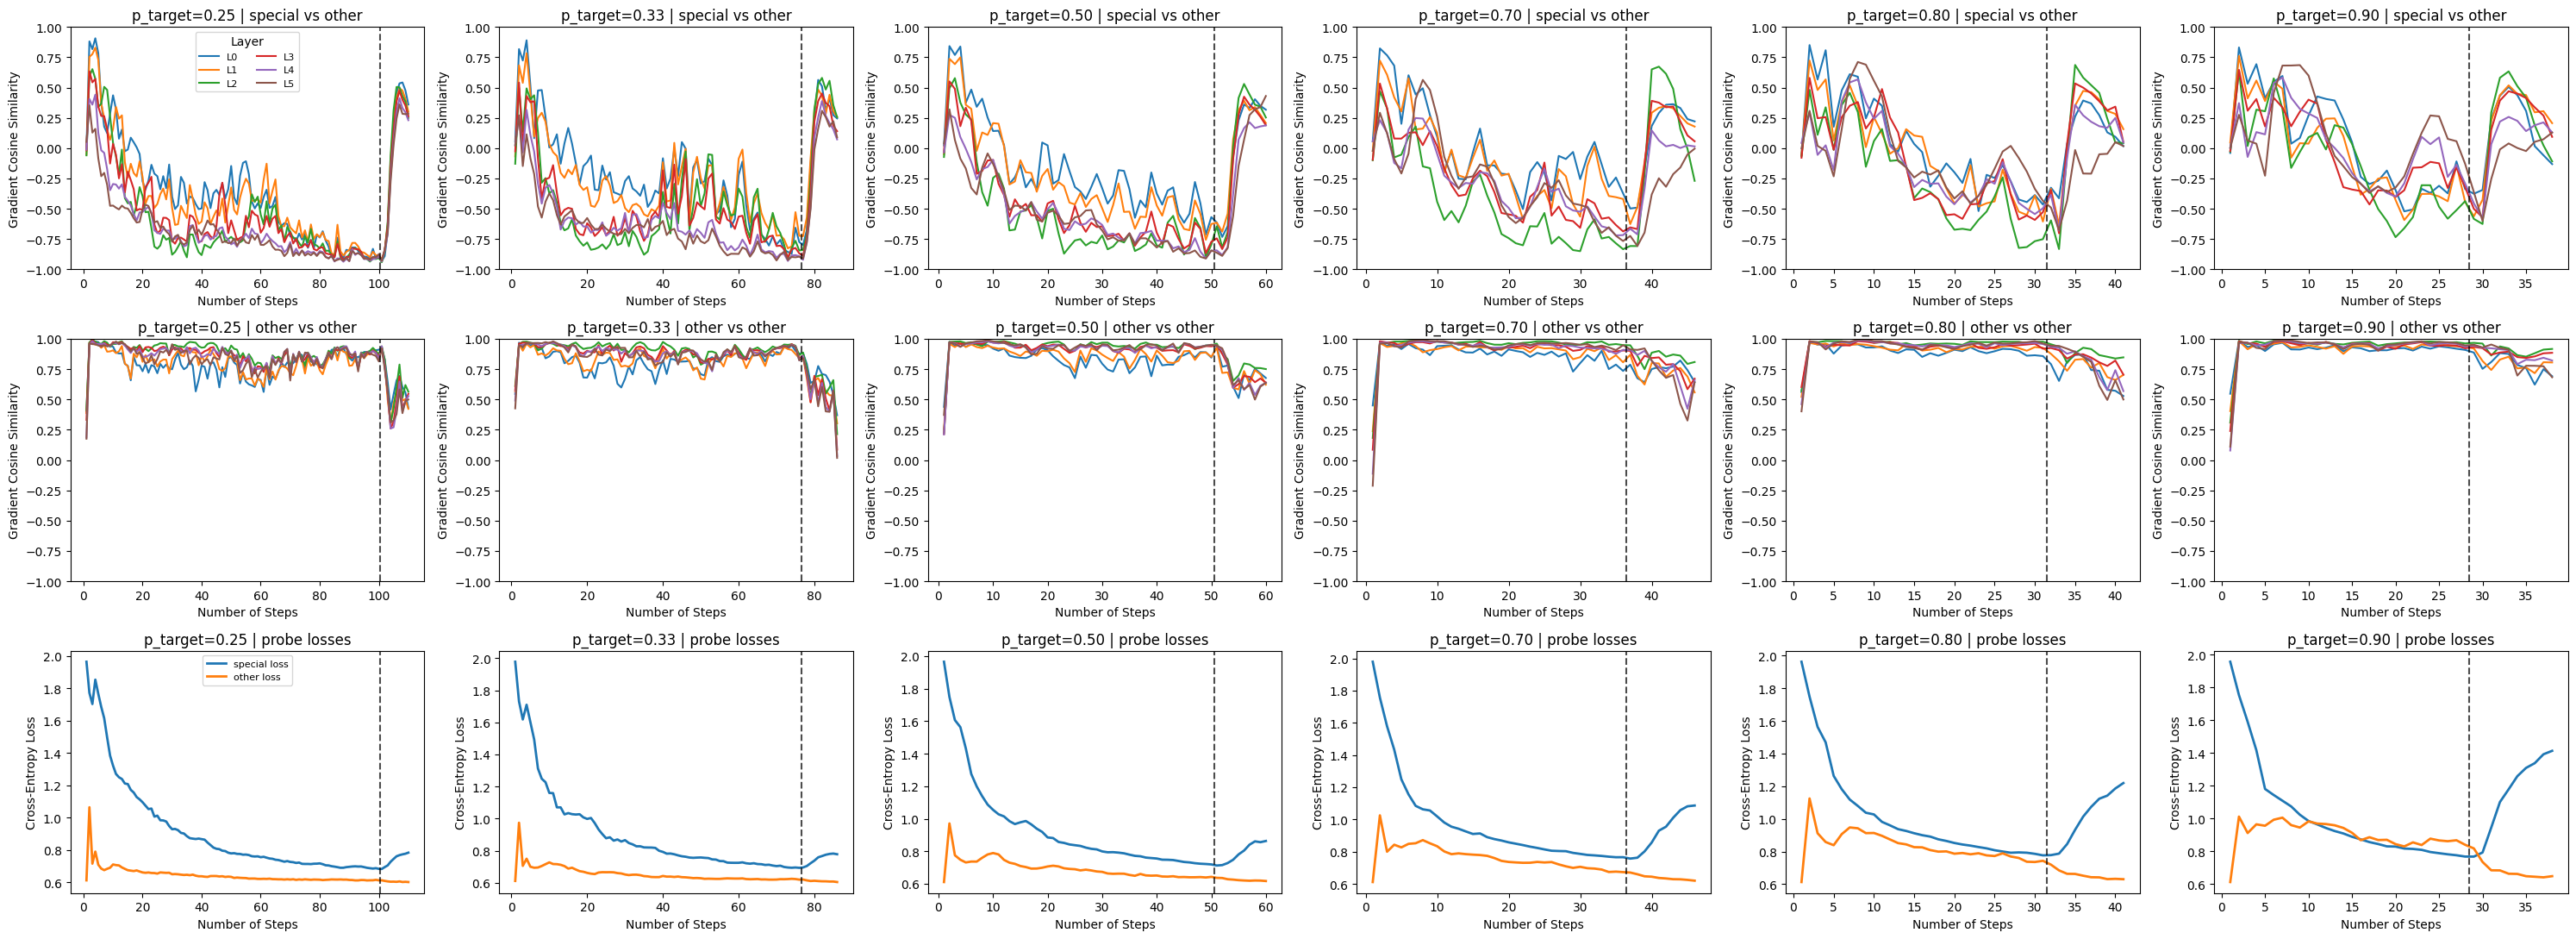

In [7]:
# Track per-layer gradient cosine similarity over training for each special concentration
import itertools
import numpy as np
import torch
import torch.nn.functional as F
from generate_data import load_model

# Uses existing globals: CKPT, STAGES, LR, WEIGHT_DECAY, BATCH_SIZE, SEED,
# target_pool/bg_pool, sample_batch, and optionally FORGET_STEPS + stage_types.

device = 'cuda' if torch.cuda.is_available() else 'cpu'
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

stages_local = parse_stages(STAGES)
steps_base = int(steps_at_p25) if 'steps_at_p25' in globals() else stages_local[0]['steps']
special_target_frac = float(SPECIAL_TARGET_FRAC) if 'SPECIAL_TARGET_FRAC' in globals() else 0.25
forget_steps_fixed = int(FORGET_STEPS) if 'FORGET_STEPS' in globals() else max(1, steps_base // 10)

# Sweep concentrations: prefer existing sweep list if available
if 'stage_types' in globals() and isinstance(stage_types, (list, tuple)) and len(stage_types) > 0:
    special_concentrations = [float(x) for x in stage_types]
else:
    special_concentrations = sorted({float(s['p_target']) for s in stages_local})

# Gradient-probe controls
GRAD_COS_EVERY = 1
GRAD_PROBE_BATCH = 64
N_OTHER_PROBES = 3  # pairwise average over these "other" gradients


def _scaled_finetune_steps(p_target):
    return max(1, int(round(steps_base * (special_target_frac / float(p_target)))))


def _grad_vector_for_block(block):
    parts = []
    for p in block.parameters():
        if p.grad is not None:
            parts.append(p.grad.detach().reshape(-1))
    if len(parts) == 0:
        return None
    return torch.cat(parts)


def _cos_safe(a, b, eps=1e-12):
    if a is None or b is None:
        return float('nan')
    an = torch.linalg.norm(a)
    bn = torch.linalg.norm(b)
    if float(an) < eps or float(bn) < eps:
        return float('nan')
    return float(torch.dot(a, b) / (an * bn))


def layer_grad_vectors(model, batch_np):
    model.zero_grad(set_to_none=True)
    batch = torch.as_tensor(batch_np, dtype=torch.long, device=device)
    logits = model(batch)
    loss = F.cross_entropy(
        logits[:, :-1, :].reshape(-1, logits.size(-1)),
        batch[:, 1:].reshape(-1),
    )
    loss.backward()

    vecs = []
    for block in model.transformer.h:
        vecs.append(_grad_vector_for_block(block))
    return vecs


@torch.no_grad()
def train_last6_acc(logits, batch):
    pred = logits[:, :-1, :].argmax(dim=-1)
    target = batch[:, 1:]
    ml = min(pred.shape[1], target.shape[1])
    last6 = max(0, ml - 6)
    return float((pred[:, last6:ml] == target[:, last6:ml]).float().mean().item())


def _batch_ce_loss(model, batch_np):
    was_training = model.training
    model.eval()
    with torch.no_grad():
        batch = torch.as_tensor(batch_np, dtype=torch.long, device=device)
        logits = model(batch)
        loss = F.cross_entropy(
            logits[:, :-1, :].reshape(-1, logits.size(-1)),
            batch[:, 1:].reshape(-1),
        )
    if was_training:
        model.train()
    return float(loss.item())


def measure_grad_cosines(model):
    sp_np = sample_batch(target_pool, bg_pool, GRAD_PROBE_BATCH, 1.0, rng)
    ot_np = sample_batch(target_pool, bg_pool, GRAD_PROBE_BATCH, 0.0, rng)

    # Probe losses requested: pure special vs pure other
    special_probe_loss = _batch_ce_loss(model, sp_np)
    other_probe_loss = _batch_ce_loss(model, ot_np)

    sp_vecs = layer_grad_vectors(model, sp_np)

    other_vec_sets = [layer_grad_vectors(model, ot_np)]
    for _ in range(max(0, N_OTHER_PROBES - 1)):
        ot_more_np = sample_batch(target_pool, bg_pool, GRAD_PROBE_BATCH, 0.0, rng)
        other_vec_sets.append(layer_grad_vectors(model, ot_more_np))

    n_layers_local = len(sp_vecs)
    sp_vs_ot = []
    ot_vs_ot = []

    for li in range(n_layers_local):
        c1 = [_cos_safe(sp_vecs[li], other_vec_sets[j][li]) for j in range(len(other_vec_sets))]
        c1 = [x for x in c1 if np.isfinite(x)]
        sp_vs_ot.append(float(np.mean(c1)) if len(c1) > 0 else float('nan'))

        pair_vals = []
        for i, j in itertools.combinations(range(len(other_vec_sets)), 2):
            v = _cos_safe(other_vec_sets[i][li], other_vec_sets[j][li])
            if np.isfinite(v):
                pair_vals.append(v)
        ot_vs_ot.append(float(np.mean(pair_vals)) if len(pair_vals) > 0 else float('nan'))

    model.zero_grad(set_to_none=True)
    return sp_vs_ot, ot_vs_ot, special_probe_loss, other_probe_loss


def run_grad_cosine_track(p_target):
    finetune_steps_local = _scaled_finetune_steps(p_target)
    forget_steps_local = forget_steps_fixed

    net_grad = load_model(str(CKPT), device=device)
    net_grad.train()
    optimizer = torch.optim.Adam(net_grad.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    n_layers_local = len(net_grad.transformer.h)

    track = {
        'step': [],
        'phase': [],
        'sp_vs_ot': [],
        'ot_vs_ot': [],
        'special_probe_loss': [],
        'other_probe_loss': [],
        'train_loss': [],
        'train_acc': [],
    }

    global_step = 0
    total_steps = finetune_steps_local + forget_steps_local

    for phase, n_steps, p_mix in [
        ('finetune', finetune_steps_local, p_target),
        ('forget', forget_steps_local, 0.0),
    ]:
        for _ in range(n_steps):
            global_step += 1

            if global_step % GRAD_COS_EVERY == 0:
                sp_ot, ot_ot, sp_loss_probe, ot_loss_probe = measure_grad_cosines(net_grad)
                track['step'].append(global_step)
                track['phase'].append(phase)
                track['sp_vs_ot'].append(sp_ot)
                track['ot_vs_ot'].append(ot_ot)
                track['special_probe_loss'].append(sp_loss_probe)
                track['other_probe_loss'].append(ot_loss_probe)

            batch_np = sample_batch(target_pool, bg_pool, BATCH_SIZE, p_mix, rng)
            batch = torch.as_tensor(batch_np, dtype=torch.long, device=device)
            logits = net_grad(batch)
            loss = F.cross_entropy(
                logits[:, :-1, :].reshape(-1, logits.size(-1)),
                batch[:, 1:].reshape(-1),
            )
            acc = train_last6_acc(logits, batch)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            track['train_loss'].append(float(loss.item()))
            track['train_acc'].append(acc)

            if global_step % 20 == 0 or global_step == 1 or global_step == total_steps:
                print(
                    f"p={p_target:.2f} step={global_step}/{total_steps} phase={phase} "
                    f"loss={loss.item():.6f} train_acc={acc:.4f}"
                )

    steps = np.asarray(track['step'], dtype=np.int64)
    sp_ot_arr = np.asarray(track['sp_vs_ot'], dtype=np.float32) if len(track['sp_vs_ot']) > 0 else np.empty((0, n_layers_local), dtype=np.float32)
    ot_ot_arr = np.asarray(track['ot_vs_ot'], dtype=np.float32) if len(track['ot_vs_ot']) > 0 else np.empty((0, n_layers_local), dtype=np.float32)
    special_probe_loss_arr = np.asarray(track['special_probe_loss'], dtype=np.float32)
    other_probe_loss_arr = np.asarray(track['other_probe_loss'], dtype=np.float32)
    return {
        'steps': steps,
        'sp_ot': sp_ot_arr,
        'ot_ot': ot_ot_arr,
        'special_probe_loss': special_probe_loss_arr,
        'other_probe_loss': other_probe_loss_arr,
        'n_layers': n_layers_local,
        'finetune_steps': finetune_steps_local,
        'forget_steps': forget_steps_local,
        'forget_start_step': finetune_steps_local + 1,
    }


all_tracks = {}
for p in special_concentrations:
    finetune_steps_local = _scaled_finetune_steps(p)
    print(
        f"\n=== Gradient-cos sweep for special concentration p_target={p:.2f} "
        f"(finetune_steps={finetune_steps_local}, forget_steps={forget_steps_fixed}) ==="
    )
    all_tracks[p] = run_grad_cosine_track(float(p))

# Plot grid: rows=metrics, cols=concentrations
n_cols = len(special_concentrations)
n_layers = next(iter(all_tracks.values()))['n_layers']
fig, axes = plt.subplots(3, n_cols, figsize=(5 * n_cols, 11), sharex=False)
if n_cols == 1:
    axes = np.asarray(axes).reshape(3, 1)

for ci, p in enumerate(special_concentrations):
    t = all_tracks[p]
    steps = t['steps']
    sp_ot = t['sp_ot']
    ot_ot = t['ot_ot']
    sp_loss = t['special_probe_loss']
    ot_loss = t['other_probe_loss']
    forget_start = t['forget_start_step'] - 0.5

    for li in range(n_layers):
        axes[0, ci].plot(steps, sp_ot[:, li], label=f'L{li}')
        axes[1, ci].plot(steps, ot_ot[:, li], label=f'L{li}')

    axes[2, ci].plot(steps, sp_loss, label='special loss', linewidth=2.0)
    axes[2, ci].plot(steps, ot_loss, label='other loss', linewidth=2.0)

    axes[0, ci].axvline(forget_start, linestyle='--', alpha=0.7, color='k')
    axes[1, ci].axvline(forget_start, linestyle='--', alpha=0.7, color='k')
    axes[2, ci].axvline(forget_start, linestyle='--', alpha=0.7, color='k')

    axes[0, ci].set_title(f'p_target={p:.2f} | special vs other')
    axes[1, ci].set_title(f'p_target={p:.2f} | other vs other')
    axes[2, ci].set_title(f'p_target={p:.2f} | probe losses')

for ci in range(n_cols):
    axes[0, ci].set_ylabel('Gradient Cosine Similarity')
    axes[1, ci].set_ylabel('Gradient Cosine Similarity')
    axes[2, ci].set_ylabel('Cross-Entropy Loss')
    axes[0, ci].set_xlabel('Number of Steps')
    axes[1, ci].set_xlabel('Number of Steps')
    axes[2, ci].set_xlabel('Number of Steps')

    axes[0, ci].set_ylim(-1.0, 1.0)
    axes[1, ci].set_ylim(-1.0, 1.0)

axes[0, 0].legend(title='Layer', fontsize=8, ncol=2)
axes[2, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()